In [1]:
import sys
# sys.path.append('.')
sys.path.append('/home/dyuser-e/dynap-se1')
import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1
import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator
import params
from params import set_params
import time
from IPython.display import Image

In [2]:
# open DYNAP-SE1 board to get Dynapse1Model

# The open_dynapse1 utility will initialize communication with the device
# - gui=False: do not open any graphical interface --> the DYNAPSE1 GUI does not work if you connect remotely
# - select_device=True: allow user/device selection if multiple boards are detected --> this is necessary when you are connecting via Zemo, since there is more than 1 board attached

model, _ = ut.open_dynapse1(gui=False, select_device=True)

# model = ut.open_specific_device_in_sequence(2)


[0]:  Bus 1 Device 74 Dynapse1DevKit serial_number 00000007
[1]:  Bus 1 Device 75 Dynapse1DevKit serial_number 00000092
[2]:  Bus 1 Device 72 Dynapse1DevKit serial_number 00000000
[3]:  Bus 1 Device 71 Dynapse1DevKit serial_number 00000001
[4]:  Bus 1 Device 70 Dynapse1DevKit serial_number 00000033
[5]:  Bus 1 Device 69 Dynapse1DevKit serial_number 00000026
Selected device:0 Dynapse1Wrapper created! libcaer init...
 00000001
Sender port: tcp://0.0.0.0:33973
Receiver port: tcp://0.0.0.0:57603
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


### Initialize Dynap-SE

In [3]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
set_params(model)                       # set standard parameters

config1     = model.get_configuration() 
param_group = config1.chips[0].cores[0].parameter_group 

### **Set Neuron/Dendrite Parameters**

In [4]:
# set AMPA (fast excitatory) weight 
param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 100
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 100    #before 70
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 80
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value =  60      #100
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group.param_map['NPDPIE_TAU_S_P'].fine_value   = 40
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

# set AMPA (fast exc) tau 
param_group.param_map['NPDPIE_TAU_F_P'].fine_value   = 60
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set GABA A (fast inhibitory) tau                              #added this
#param_group.param_map['NPDPII_TAU_F_P'].fine_value = 40
#param_group.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group.param_map['NPDPII_TAU_S_P'].fine_value = 100
param_group.param_map['NPDPII_TAU_S_P'].coarse_value = 4

# Neuron membrane voltage gain
#param_group.param_map['IF_THR_N'].fine_value = 120
#param_group.param_map['IF_THR_N'].coarse_value = 4



In [5]:
# print AMPA weight values

print("\n--- AMPA (fast excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))


# print NMDA (slow excitatory) weight

print("\n--- NMDA (slow excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))


# print GABA B (slow inhibitory) weight

print("\n--- GABA B (slow inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))


# print GABA A (fast inhibitory) weight

print("\n--- GABA A (fast inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))


# print NMDA (slow exc) tau

print("\n--- NMDA tau (slow excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))


# print AMPA (fast exc) tau

print("\n--- AMPA tau (fast excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))


--- AMPA (fast excitatory) weight ---
Linear: 15686275.0
Coarse: 5
Fine: 100

--- NMDA (slow excitatory) weight ---
Linear: 15686275.0
Coarse: 5
Fine: 100

--- GABA B (slow inhibitory) weight ---
Linear: 12549020.0
Coarse: 5
Fine: 80

--- GABA A (fast inhibitory) weight ---
Linear: 9411765.0
Coarse: 5
Fine: 60

--- NMDA tau (slow excitatory) ---
Linear: 784314.0
Coarse: 4
Fine: 40

--- AMPA tau (fast excitatory) ---
Linear: 1176471.0
Coarse: 4
Fine: 60


### **Set Network Parameters**

In [6]:

model.update_parameter_group(param_group, 0, 0)

NE = 16          # neurons per excitatory state population
NI = 11          # inhibitory population size
NS = 2           # number of excitatory state populations   #add the second and then the third
NG = 2           # Nr of spike generators   # add the second and then the third

#p_S_S = 1      # recurrent excitation within each state population / fraction of     
#p_S_I = 0.7      # excitation from each state population to inhibitory pool    
#p_I_S = 0.7      # inhibition from inhibitory pool to all state populations    0.3
#p_I_I = 0.0      # optional inhibitory recurrence
#p_G_S = 0.5      # spike generator to state population

p_S_S_AMPA  = 0.8  # Base Prob #before 0.6
p_S_S_NMDA  = 0.2  # NMDA/AMPA #before 0.3
p_S_I       = 0.6      # excitation from each state population to inhibitory pool #before 0.6
p_I_S_GABA_A  = 0.4      # Base Prob
p_I_S_GABA_B  = 0.9      # GABA_B/GABA_A
p_I_I       = 0      # optional inhibitory recurrence
p_G_S       = 0.2      # spike generator to state population
p_S_S_self  = 0.5
p_I_I_self  = 0.0


lr    = 40      # low rate (Hz)
hr    = 80      # high rate (Hz) 

stim_rates = np.linspace(lr,lr,20) # stimulation rates to test (Hz) minimum, maximum and number of rates to test
stim_rates_hz = [[rate, rate, 0] for rate in stim_rates ]

stim_rates_hz[6][0:2] = [hr, lr]
stim_rates_hz[7][0:2] = [hr, lr]
stim_rates_hz[14][0:2] = [lr, hr]
stim_rates_hz[15][0:2] = [lr, hr]

dt_stim       = 0.5  # duration of each stimulus (s)
t_steps_stim  = dt_stim*np.ones_like(stim_rates)
t_post_stim   = 2.0
t_tot         = sum(t_steps_stim) + t_post_stim

print(stim_rates_hz)
print(t_tot)

[[40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [80, 40, 0], [80, 40, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40, 80, 0], [40, 80, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0], [40.0, 40.0, 0]]
12.0


In [7]:

fs          = 4             # rate estimate sampling frequency
sigma_s     = 0.01             # gaussian smoothing width in seconds
seed        = 1
rng = np.random.default_rng(seed)


net_gen = NetworkGenerator()
net_gen.clear_network()


spikegen_ids = [(0, 1, i + 1) for i in range(NG)]                                                          # chip, core, neuron
spikegens    = [Neuron(chip, core, nid, True) for chip, core, nid in spikegen_ids]



### Build Network

#### Connection Matrix

In [8]:
# ------------------------------------------------------------
# CONSTRUCT CONNECTION MATRIX
# ------------------------------------------------------------

N_hw  = NE * NS + NI   # all real neurons (core 0)
N_tot = N_hw + NG      # total including spike gens

C = np.zeros((N_tot, N_tot))

def get_idx(n):
    # real neurons (core 0)
    if n.core_id == 0:
        return n.neuron_id - 1

    # spike generators (core 1)
    elif n.core_id == 1:
        return N_hw + (n.neuron_id - 1)

    else:
        raise ValueError("Unknown core_id")

def add_conn(src, tgt, syn_type):
    net_gen.add_connection(src, tgt, syn_type)

    src_idx = get_idx(src)
    tgt_idx = get_idx(tgt)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_idx, tgt_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_idx, tgt_idx] = -1
    
    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_idx, tgt_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_idx, tgt_idx] = -2

#### Network

In [9]:

S_pops = []
E_ids  = []

next_neuron_id = 1
for s in range(NS):
    pop_ids = [(0, 0, nid) for nid in range(next_neuron_id, next_neuron_id + NE)]
    pop     = [Neuron(chip, core, nid) for chip, core, nid in pop_ids]

    S_pops.append(pop)
    E_ids.extend(pop_ids)

    next_neuron_id += NE


I_ids = [(0, 0, nid) for nid in range(next_neuron_id, next_neuron_id + NI)]
I_pop = [Neuron(chip, core, nid) for chip, core, nid in I_ids]


# ------------------------------------------------------------
# CONNECT SPIKEGENS -> STATE POPULATIONS - DETERMINISTIC
# ------------------------------------------------------------
for j in range(NS):
    k = 0
    for neuron in S_pops[j]:
        if k < NE * p_G_S:
            add_conn(spikegens[j], neuron, dyn1.Dynapse1SynType.AMPA)
            k += 1

# ------------------------------------------------------------
# CONNECT S_i -> S_i (Probabilistic E recurrence)   #before NMDA
# ------------------------------------------------------------
for s in range(NS):
    for i in range(NE):
        for j in range(NE):
            if i == j and rng.random() < p_S_S_self:
                if rng.random() < p_S_S_NMDA:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.NMDA)
                else:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.AMPA
                    )
                    
            if i != j and rng.random() < p_S_S_AMPA:
                if rng.random() < p_S_S_NMDA:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.NMDA)
                else:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.AMPA
                    )


# ------------------------------------------------------------
# CONNECT S_i -> I (Probabilistic)
# ------------------------------------------------------------
for s in range(NS):
    for e_neuron in S_pops[s]:
        for i_neuron in I_pop:
            if rng.random() < p_S_I:
                add_conn(
                    e_neuron,
                    i_neuron,
                    dyn1.Dynapse1SynType.AMPA
                )

# ------------------------------------------------------------
# CONNECT I -> S_i (Probabilistic)
# ------------------------------------------------------------
for i_neuron in I_pop:
    for s in range(NS):
        for e_neuron in S_pops[s]:
            if rng.random() < p_I_S_GABA_A:
                if rng.random() < p_I_S_GABA_B:
                    add_conn(
                        i_neuron,
                        e_neuron,
                        dyn1.Dynapse1SynType.GABA_B
                    )
                else:
                    add_conn(
                        i_neuron,
                        e_neuron,
                        dyn1.Dynapse1SynType.GABA_A
                    )

# ------------------------------------------------------------
# CNNECT I -> I (Probabilistic)
# ------------------------------------------------------------
if p_I_I > 0:
    for i in range(NI):
        for j in range(NI):
            if i == j and rng.random() < p_I_I_self:
                add_conn(
                    I_pop[i],
                    I_pop[j],
                    dyn1.Dynapse1SynType.GABA_A
                )
            if i != j and rng.random() < p_I_I:
                add_conn(
                    I_pop[i],
                    I_pop[j],
                    dyn1.Dynapse1SynType.GABA_A
                )

### **Plot Connection Matrix**

plt.clf()      # clear current figure
plt.close('all')  # close all existing figures

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    C,
    interpolation='none',
    aspect='equal',
    vmin=-1,
    vmax=1
)
ax.set_xticks(np.arange(N_tot + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(N_tot + 1) - 0.5, minor=True)

ax.grid(which='minor', color='black', linestyle='-', linewidth=0.3)

ax.tick_params(which='minor', bottom=False, left=False)

ax.axhline(NE * NS - 0.5, color='white', linewidth=0.4)
ax.axvline(NE * NS - 0.5, color='white', linewidth=0.4)

ax.axhline(N_hw - 0.5, color='white', linewidth=0.4)
ax.axvline(N_hw - 0.5, color='white', linewidth=0.4)

ax.set_xlabel("target neuron")
ax.set_ylabel("source neuron")

ax.set_title("Connectivity matrix")

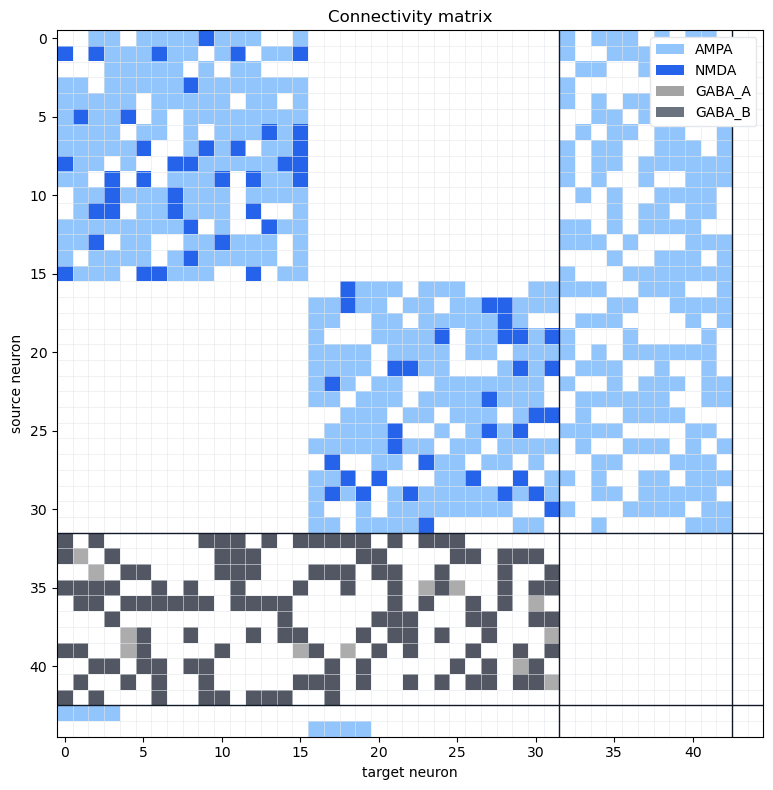

In [10]:

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

plt.clf()
plt.close('all')

fig, ax = plt.subplots(figsize=(8, 8))

# ------------------------------------------------------------
# DISCRETE SYNAPSE COLORS
# ------------------------------------------------------------
values = [-2, -1, 0, 1, 2]

colors = [
    "#525763",  # GABA_B  dark grey-blue
    "#acacac",  # GABA_A  light grey
    "#ffffff",  # no connection
    "#93c5fd",  # AMPA    soft blue
    "#2563eb",  # NMDA    deeper blue
]

cmap = ListedColormap(colors)

# Boundaries halfway between integer values
bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

im = ax.imshow(
    C,
    cmap=cmap,
    norm=norm,
    interpolation='none',
    aspect='equal'
)

# ------------------------------------------------------------
# GRID
# ------------------------------------------------------------
ax.set_xticks(np.arange(N_tot + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(N_tot + 1) - 0.5, minor=True)

ax.grid(
    which='minor',
    color='#e5e7eb',
    linestyle='-',
    linewidth=0.4
)

ax.tick_params(which='minor', bottom=False, left=False)

# ------------------------------------------------------------
# POPULATION BOUNDARIES
# ------------------------------------------------------------
boundary_color = '#111827'

ax.axhline(NE * NS - 0.5, color=boundary_color, linewidth=1.0)
ax.axvline(NE * NS - 0.5, color=boundary_color, linewidth=1.0)

ax.axhline(N_hw - 0.5, color=boundary_color, linewidth=1.0)
ax.axvline(N_hw - 0.5, color=boundary_color, linewidth=1.0)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------
ax.set_xlabel("target neuron")
ax.set_ylabel("source neuron")
ax.set_title("Connectivity matrix")

# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
legend_elements = [
    Patch(facecolor="#93c5fd", edgecolor='none', label='AMPA'),
    Patch(facecolor="#2563eb", edgecolor='none', label='NMDA'),
    Patch(facecolor="#a3a3a3", edgecolor='none', label='GABA_A'),
    Patch(facecolor="#6b7280", edgecolor='none', label='GABA_B'),
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=True,
    framealpha=1.0,
    edgecolor='#e5e7eb'
)

plt.tight_layout()
plt.show()

In [11]:
# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

set_params(model, param_group=param_group)

# ------------------------------------------------------------
# PREPARE POISSON INPUT
# ------------------------------------------------------------
global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------
monitored_neurons = E_ids + I_ids + [(0,1,1)] + [(0,1,2)] + [(0,1,3)]         # monitor all excitatory and inhibitory neurons and the spike generators
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()
# filter_node.set_neurons(monitored_neurons)

# clear buffer
sink_node.get_events()
api.reset_timestamp()

New configuration applied to DYNAP-SE1!


In [12]:
# ------------------------------------------------------------
# CREATE POISSON SPIKE TIMES
# ------------------------------------------------------------
spike_times  = []
indices      = []
target_chips = []

t0 = 0.0

for i, duration in enumerate(t_steps_stim):

    for gen_id, rate in zip(global_poisson_gen_ids, stim_rates_hz[i]):

        n_spikes = np.random.poisson(rate * duration)
        
        print("n_spikes", n_spikes)

        times = t0 + np.sort(np.random.rand(n_spikes) * duration)
        
        print("times", times)
        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([0] * n_spikes)

    t0 += duration


# Then sort all spikes globally in time:
spike_times  = np.array(spike_times)
indices      = np.array(indices)
target_chips = np.array(target_chips)

sort_idx = np.argsort(spike_times)

spike_times  = spike_times[sort_idx]
indices      = indices[sort_idx]
target_chips = target_chips[sort_idx]


# Then load the stimulus:
fpga_spike_gen = model.get_fpga_spike_gen()

ut.set_fpga_spike_gen(
    fpga_spike_gen = fpga_spike_gen,
    spike_times    = spike_times,
    indices        = indices,
    target_chips   = target_chips,
    isi_base       = 900,
    repeat_mode    = False
)

n_spikes 24
times [0.0155903  0.02974666 0.03945592 0.04506415 0.05670461 0.06765191
 0.08370766 0.11541177 0.11864956 0.14783056 0.15230077 0.15741119
 0.19505042 0.23143213 0.27839285 0.28317092 0.34669639 0.3764942
 0.38202854 0.41741497 0.44395128 0.46733539 0.47203019 0.47758342]
n_spikes 25
times [0.00475158 0.01096559 0.02586456 0.05802272 0.08319252 0.08321906
 0.11519093 0.11620943 0.1224257  0.12286752 0.12367878 0.13676944
 0.17571477 0.18846898 0.21899791 0.24204296 0.24622497 0.25858231
 0.27634834 0.283653   0.28383531 0.29622821 0.36042313 0.44957597
 0.48809607]
n_spikes 18
times [0.52075171 0.5321296  0.56067602 0.67663934 0.6912896  0.70177195
 0.70751912 0.71018748 0.72500555 0.73506842 0.78764922 0.78801105
 0.84127409 0.84625457 0.88388131 0.9021454  0.93799135 0.94914124]
n_spikes 21
times [0.51433613 0.52535099 0.55814506 0.56036722 0.57944315 0.58014103
 0.60972872 0.66387904 0.66539488 0.71180194 0.71905215 0.79251004
 0.85402077 0.86009449 0.88270562 0.8948469

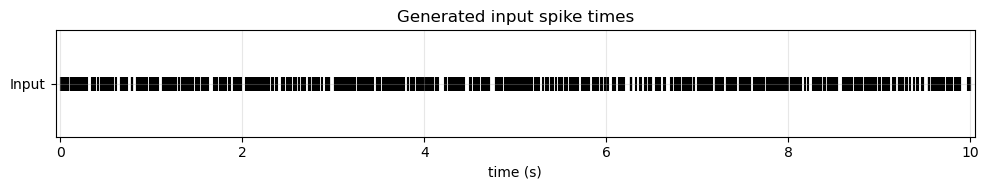

In [13]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.scatter(
    spike_times,
    -1 * np.ones_like(spike_times),
    marker='|',
    s=100,
    color='black'
)

ax.set_xlabel('time (s)')
ax.set_yticks([-1])
ax.set_yticklabels(['Input'])
ax.set_title('Generated input spike times')
ax.set_xlim(-0.05, t0 + 0.05)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Run Simulation**

In [14]:
# Run Simulation

#for i, t in enumerate(t_steps_stim):
    #for gid, rate in zip(global_poisson_gen_ids, stim_rates_hz[i]):
        #poisson_gen.write_poisson_rate_hz(gid, rate)

    #poisson_gen.start()
    #time.sleep(t)

# Run Simulation freq fissa
fpga_spike_gen.start()
time.sleep(t0)
fpga_spike_gen.stop()

# turn off stimulus

for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

poisson_gen.stop()
time.sleep(t_tot)

graph.stop()
events = sink_node.get_events()

print(f"{len(events)} events recorded.")

PoissonGen already off!
2591 events recorded.


### **Post Simulation Processing**

In [15]:
# ------------------------------------------------------------
# EXTRACT EVENTS
# ------------------------------------------------------------
spike_id = []
spike_t  = []

for evt in events:
    spike_id.append(evt.neuron_id)
    spike_t.append(evt.timestamp * 1e-6)

spike_id = np.array(spike_id)
spike_t  = np.array(spike_t)


# ------------------------------------------------------------
# FILTER SPIKES BY POPULATION
# ------------------------------------------------------------
S_spike_t  = []
S_spike_id = []

for s in range(int(NS)):
    lower = s * NE
    upper = (s + 1) * NE

    mask = (spike_id > lower) & (spike_id <= upper)

    S_spike_t.append(spike_t[mask])
    S_spike_id.append(spike_id[mask])

#I_spike_t = []
#I_spike_id =[]
mask_I = spike_id > NS * NE

I_spike_t  = spike_t[mask_I]
I_spike_id = spike_id[mask_I]

#for s in range(int(NI)):
    #lower = s * NI
    #upper = (s + 1) * NI
#lower = NS * NE + s * NI_per_group
#upper = NS * NE + (s + 1) * NI_per_group

    #mask = (spike_id > lower) & (spike_id <= upper)
#I_spike_t.append(spike_t[mask])
#I_spike_id.append(spike_id[mask])


# ------------------------------------------------------------
# BIN FILTERED SPIKES
# ------------------------------------------------------------
fs     = 4
n_bins = int(t_tot * fs)

binPOP = np.zeros((NS+1, n_bins))

#for s in range(int(NS)):
    #bin_idx = (S_spike_t[s] * fs).astype(int)

    #bin_idx = bin_idx[bin_idx < n_bins]

    #binPOP[s, bin_idx] += 1

for s in range(int(NS + 1)):

    if s < NS:
        t_spikes = S_spike_t[s]
    else:
        t_spikes = I_spike_t   # last row = inhibitory population

    t_spikes = t_spikes[t_spikes < t_tot]

    counts, _ = np.histogram(
        t_spikes,
        bins=n_bins,
        range=(0, t_tot)
    )

    binPOP[s, :] = counts

# total excitatory activity (all S populations pooled)
#binPOP_E = np.sum(binPOP, axis=0)
binPOP_E = np.sum(binPOP[:NS, :], axis=0)

# Mean excitatory activity (all S populations pooled)
#binPOP_E_mean = binPOP_E / (NS * NE)
binPOP_tot_mean = np.sum(binPOP) / (NS * NE)

# ------------------------------------------------------------
# POPULATION FIRING ACTIVITY
# ------------------------------------------------------------
idx_end = int(t_tot * fs)
t_axis  = np.arange(idx_end) / fs

binPOP_rate = binPOP[:, :idx_end] * fs / NE



# ------------------------------------------------------------
# FIRING ACTIVITY PER STIMULUS WINDOW
# ------------------------------------------------------------

#TODO Make independent of binPOP

stim_start = np.cumsum(np.r_[0, t_steps_stim[:-1]])
stim_end   = stim_start + t_steps_stim

out_rates = np.zeros((NS, len(stim_rates_hz)))

for s in range(int(NS)):
    for i, (t0, t1) in enumerate(zip(stim_start, stim_end)):
        b0 = int(t0 * fs)
        b1 = int(t1 * fs)

        n_spikes = np.sum(binPOP[s, b0:b1])

        out_rates[s, i] = n_spikes / (t1 - t0)



In [16]:
#input_spike_t  = spike_times
#input_spike_id = indices

#fig, ax = plt.subplots(figsize=(6, 3))

#for gid in np.unique(input_spike_id):
    #mask = input_spike_id == gid
    #ax.scatter(
        #input_spike_t[mask],
        #input_spike_id[mask],
        #marker='|',
        #label=f'G{gid}'
    #)

#ax.set_xlabel('time (s)')
#ax.set_ylabel('spike generator id')
#ax.set_title('Exact Poisson input sent to FPGA')
#ax.legend()
#ax.grid(True, alpha=0.3)

#plt.tight_layout()
#plt.show()

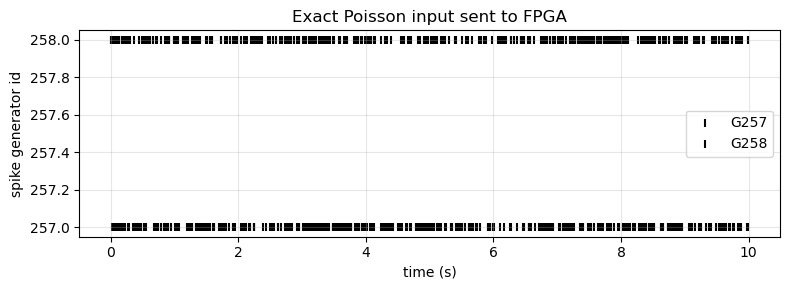

In [17]:
input_spike_t  = spike_times
input_spike_id = indices

color_in = 'black'

fig, ax = plt.subplots(figsize=(8, 3))

for gid in np.unique(input_spike_id):
    mask = input_spike_id == gid
    ax.scatter(
        input_spike_t[mask],
        input_spike_id[mask],
        marker='|',
        s = 30,
        color = color_in,
        label=f'G{gid}'
    )

ax.set_xlabel('time (s)')
ax.set_ylabel('spike generator id')
ax.set_title('Exact Poisson input sent to FPGA')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_290066/2839814230.py:117: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax3.set_xlim(stim_rates[0], stim_rates[-1])


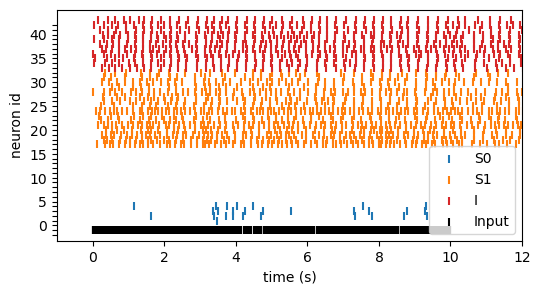

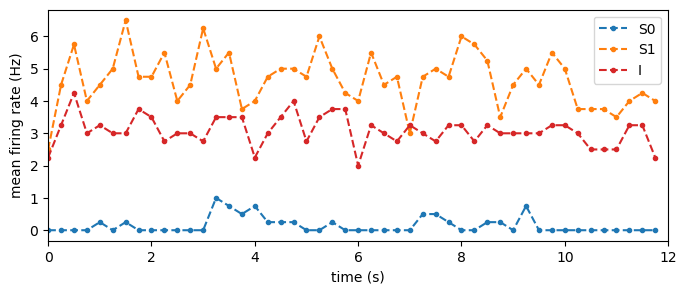

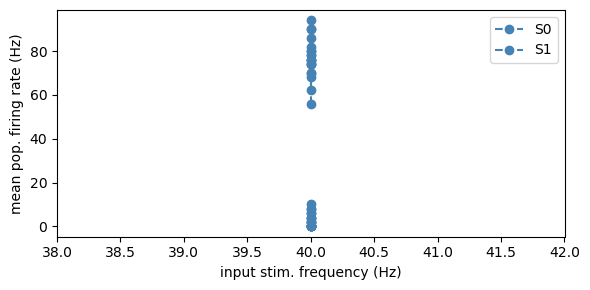

In [18]:

color_I  = 'tab:red'
color_S  = ['tab:blue', 'tab:orange', 'tab:green', color_I]  # one per S population

# ------------------------------------------------------------
# PLOT SPIKE RASTER
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(6, 3))

for s in range(int(NS)):
    ax1.scatter(
        S_spike_t[s],
        S_spike_id[s],
        marker='|',
        color=color_S[s],
        label=f'S{s}'
    )

if I_spike_t.size > 0:
     ax1.scatter(
        I_spike_t,
        I_spike_id,
        marker='|',
        color= color_I,
        label='I'
    )

#ax1.scatter(
    #I_spike_t,
    #I_spike_id,
    #marker='|',
    #label='I'
#)

ax1.scatter(
    input_spike_t,
    -1 * np.ones_like(input_spike_t),
    marker='|',
    color= color_in,
    label='Input'
)


ticks = np.arange(-NG, NS*NE + NI, 1)
#ticks = np.arange(0, NE, 1)
ax1.set_yticks(ticks)

# show labels only every k neurons
k = 5
labels = [str(t) if t % k == 0 else '' for t in ticks]
ax1.set_yticklabels(labels)

ax1.set_xlabel('time (s)')
ax1.set_ylabel('neuron id')
ax1.set_xlim(-1, t_tot)
ax1.legend()


# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST TIME
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 3))

for s in range(int(NS)):
    ax2.plot(
        t_axis,
        binPOP_rate[s],
        marker      = 'o',
        linestyle   = '--',
        color       = color_S[s],
        markersize  = 3,
        label       = f'S{s}'
    )

if I_spike_t.size > 0:
     ax2.plot(
            t_axis,
            binPOP_rate[NS],
            marker     = 'o',
            linestyle  = '--',
            color      = color_I,
            markersize = 3,
            label      = f'I'
        )

ax2.set_xlabel('time (s)')
ax2.set_ylabel('mean firing rate (Hz)')
ax2.set_xlim(0, t_tot)
ax2.legend()


# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST INPUT STIMULUS
# ------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(6, 3))

for s in range(int(NS)):
    ax3.plot(
        stim_rates,
        out_rates[s],
        marker='o',
        linestyle='--',
        color='steelblue',
        label=f'S{s}'
    )

#ax3.plot(
    #stim_rates,
    #np.mean(out_rates_I, axis=0),
    #marker='o',
    #linestyle=':',
    #color='red',
    #label='Inhibitory'
#)

ax3.set_xlabel('input stim. frequency (Hz)')
ax3.set_ylabel('mean pop. firing rate (Hz)')
ax3.set_xlim(stim_rates[0], stim_rates[-1])
ax3.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST TIME
# ------------------------------------------------------------
# maybe copy and paste gr 2 but on the x put out_rates and outrates_I

#fig4, ax4 = plt.subplots(figsize=(6, 3))

#for s in range(int(NS)):
    #ax4.plot(
        #t_axis,
        #out_rates[s],
        #marker='o',
        #color='steelblue',
        #linestyle=':',
        #label=f'S{s}'
    #)

#ax4.plot(
 #   t_axis,
  #  np.mean(out_rates_I, axis=0),
   # marker='o',
    #linestyle=':',
    #color='red',
    #label='Inhibitory'
#)

#ax4.set_xlabel('time (s)')
#ax4.set_ylabel('mean firing rate (Hz)')
#ax4.set_xlim(0, t_tot)
#ax4.legend()
    

In [19]:
print("out_rates:", out_rates)
#print("out_rates_I mean:", np.mean(out_rates_I, axis=0))

out_rates: [[ 0.  0.  2.  2.  0.  0.  8. 10.  8.  4.  0.  2.  0.  0.  4.  6.  0.  4.
   6.  0.]
 [56. 78. 76. 90. 82. 68. 90. 74. 70. 80. 86. 74. 76. 74. 62. 78. 94. 70.
  76. 80.]]


### **Plot Stimulation Rates**

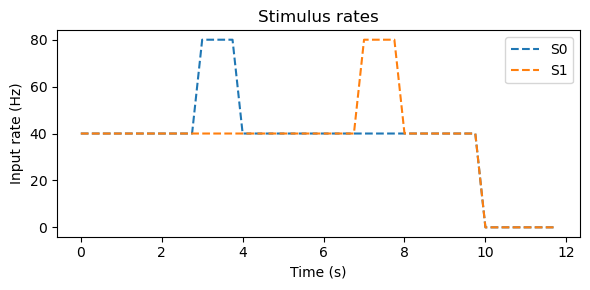

In [20]:

fs = 4

stim_rates_hz = np.array(stim_rates_hz)
t             = np.arange(0, t_tot, 1/fs)

# allocate rate matrix
rates = np.zeros((NS, len(t)))

# fill piecewise constant segments
t_cursor = 0
for i, dt in enumerate(t_steps_stim):
    idx_start = int(t_cursor * fs)
    idx_end   = int((t_cursor + dt) * fs)

    for s in range(NS):
        rates[s, idx_start:idx_end] = stim_rates_hz[i, s],

    t_cursor += dt

plt.figure(figsize=(6,3))

for s in range(NS):
    plt.plot(t, rates[s], label=f"S{s}", linestyle='--')

plt.xlabel("Time (s)")
plt.ylabel("Input rate (Hz)")
plt.title("Stimulus rates")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
from tools.spikegen_tools import get_instantaneous_activity


# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.2
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < t_tot)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, t_tot, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < t_tot

    activity_rate = activity_hz[mask] / n_neurons
    activity_x    = activity_x[mask]

    return activity_rate, activity_x


S_activity_rate = []
S_activity_x    = []

for s in range(int(NS)):
    rate, x = population_activity(S_spike_t[s], NE)

    S_activity_rate.append(rate)
    S_activity_x.append(x)


I_activity_rate, I_activity_x = population_activity(I_spike_t, NI)


# total excitatory activity, all S populations pooled
E_spike_t = np.concatenate(S_spike_t)

E_activity_rate, E_activity_x = population_activity(
    E_spike_t,
    int(NS) * NE
)

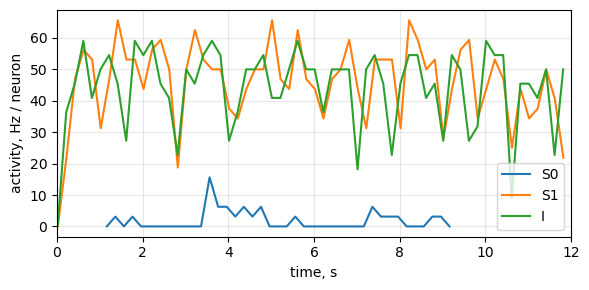

In [22]:
# ------------------------------------------------------------
# PLOT INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(6, 3))

for s in range(int(NS)):
    ax2.plot(
        S_activity_x[s],
        S_activity_rate[s],
        label=f"S{s}"
    )

ax2.plot(
    I_activity_x,
    I_activity_rate,
    label="I"
)

ax2.set_xlabel("time, s")
ax2.set_ylabel("activity, Hz / neuron")
ax2.set_xlim(0, t_tot)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()